In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:

df = pd.read_csv('../data/bank/bank-full.csv', sep=';')
df.shape

(45211, 17)

In [9]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [14]:
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [16]:
df.dtypes.value_counts()


str      10
int64     7
Name: count, dtype: int64

In [20]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [22]:
df['y'].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

We wanted to check the proportions of the two outputs to understand which metric to use, like we found the proportion here to be 88 percent and 11 percent roughly so if I use a bad model which predicts no everytime it will hsve a prediction of 88 percent which is a bad metric.

Observations so far
y is heavily imbalanced.
There are no actual missing values.
There are numerical and categorical variables.
duration may be unavailable in a genuine pre-call prediction setting.

In [27]:
job_props = pd.crosstab(df['job'], df['y'], normalize='index')
subscription_rate = job_props['yes']*100
subscription_rate = subscription_rate.sort_values(ascending=False)

C:\Users\M T Sulthana\AppData\Local\Temp\ipykernel_21988\873090410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subscription_rate.values, y=subscription_rate.index, palette='viridis')


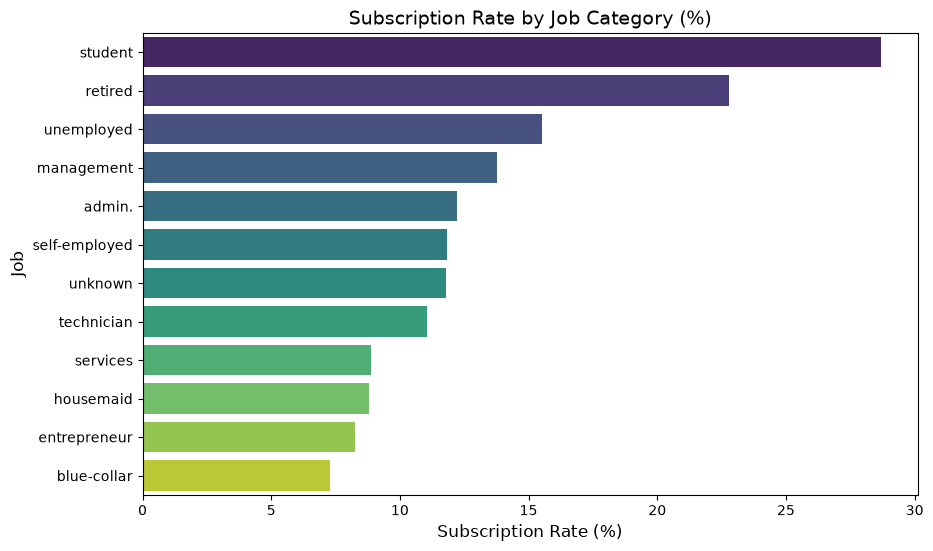

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=subscription_rate.values, y=subscription_rate.index, palette='viridis')

plt.title('Subscription Rate by Job Category (%)', fontsize=14)
plt.xlabel('Subscription Rate (%)', fontsize=12)
plt.ylabel('Job', fontsize=12)

plt.show()

In [43]:
df[df['y']=='yes']['job'].value_counts()

job
management       1301
technician        840
blue-collar       708
admin.            631
retired           516
services          369
student           269
unemployed        202
self-employed     187
entrepreneur      123
housemaid         109
unknown            34
Name: count, dtype: int64

Text(0, 0.5, 'Age')

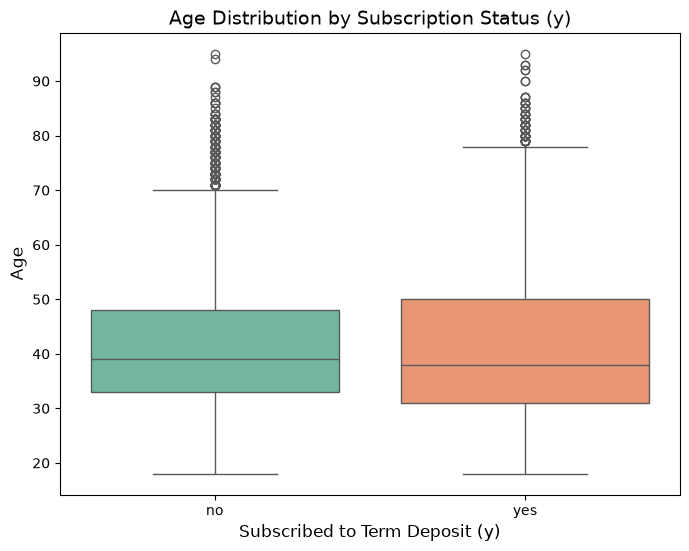

In [44]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x='y', y='age', hue='y', palette='Set2', legend=False)

plt.title('Age Distribution by Subscription Status (y)', fontsize=14)
plt.xlabel('Subscribed to Term Deposit (y)', fontsize=12)
plt.ylabel('Age', fontsize=12)

Text(0, 0.5, 'Income')

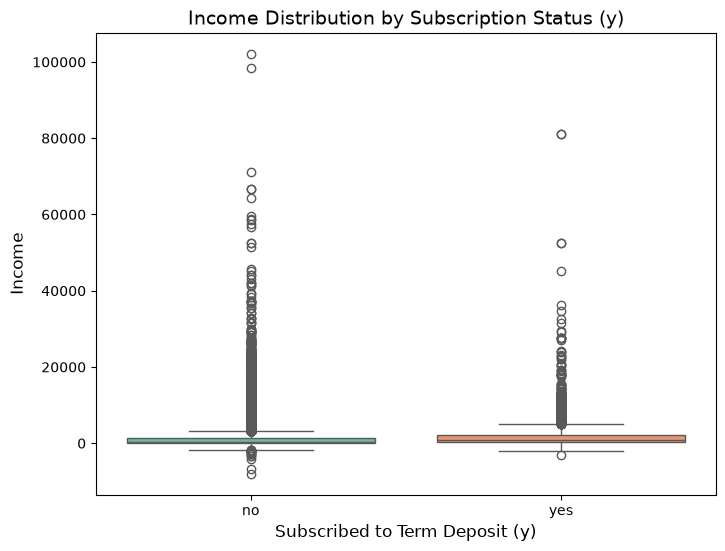

In [46]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x='y', y='balance', hue='y', palette='Set2', legend=False)

plt.title('Income Distribution by Subscription Status (y)', fontsize=14)
plt.xlabel('Subscribed to Term Deposit (y)', fontsize=12)
plt.ylabel('Income', fontsize=12)